## ЧАСТЬ 1: Feature engineering
Перед созданием модели нужно обработать уже существующие признаки и добавить новые с предиктивным потенциалом.

In [1]:
import pandas as pd

taxi = pd.read_parquet("../data/processed/final_dataset_2025.parquet")
taxi.head(3)

,date,hour,LocationID,pickups,event_day,weekday
0,2025-01-01,0,79,353,0,Wednesday
1,2025-01-01,0,161,274,0,Wednesday
2,2025-01-01,0,163,161,0,Wednesday


In [2]:
taxi.shape

(43800, 6)

Добавим признаки lag_24 и lag_168, которые будут показывать, сколько поездок случилось в это время в этой зоне вчера и неделю назад, соответственно. Для начала отсортируем таблицу по LocationID, date, hour. Тогда нужно будет просто взять значения из ячейки на 24 и 168 строк выше.

In [3]:
taxi = taxi.sort_values(['LocationID', 'date', 'hour']).reset_index(drop=True)
taxi

,date,hour,LocationID,pickups,event_day,weekday
0,2025-01-01,0,79,353,0,Wednesday
1,2025-01-01,1,79,474,0,Wednesday
2,2025-01-01,2,79,492,0,Wednesday
3,2025-01-01,3,79,447,0,Wednesday
4,2025-01-01,4,79,207,0,Wednesday
...,...,...,...,...,...,...
43795,2025-12-31,19,239,259,1,Wednesday
43796,2025-12-31,20,239,216,1,Wednesday
43797,2025-12-31,21,239,229,1,Wednesday
43798,2025-12-31,22,239,162,1,Wednesday


In [4]:
taxi["lag_24"] = taxi.groupby("LocationID")["pickups"].shift(24)
taxi["lag_168"] = taxi.groupby("LocationID")["pickups"].shift(168)
taxi

,date,hour,LocationID,pickups,event_day,weekday,lag_24,lag_168
0,2025-01-01,0,79,353,0,Wednesday,NaN,NaN
1,2025-01-01,1,79,474,0,Wednesday,NaN,NaN
2,2025-01-01,2,79,492,0,Wednesday,NaN,NaN
3,2025-01-01,3,79,447,0,Wednesday,NaN,NaN
4,2025-01-01,4,79,207,0,Wednesday,NaN,NaN
...,...,...,...,...,...,...,...,...
43795,2025-12-31,19,239,259,1,Wednesday,150.0,187.0
43796,2025-12-31,20,239,216,1,Wednesday,117.0,125.0
43797,2025-12-31,21,239,229,1,Wednesday,126.0,144.0
43798,2025-12-31,22,239,162,1,Wednesday,116.0,101.0


In [5]:
taxi.isna().sum()

date            0
hour            0
LocationID      0
pickups         0
event_day       0
weekday         0
lag_24        120
lag_168       840
dtype: int64

Ожидаемо в каждой зоне по 24 пропуска в "lag_24" и по 168 пропусков в "lag_168". Надо обработать их: добавлю дополнительные признаки, указывающие на то, что пропуск был, и заполню пропуски 0.

In [6]:
taxi["lag_24_missing"] = taxi["lag_24"].isna().astype(int)
taxi["lag_168_missing"] = taxi["lag_168"].isna().astype(int)

taxi[["lag_24", "lag_168"]] = taxi[["lag_24", "lag_168"]].fillna(0)

При изучении данных о поездках на жёлтых такси для составления итогового датасета, я заметила, что в праздничные дни происходит падение количества поездок. Потому надо добавить очень важный признак "is_holiday", релевантный именно США.

In [7]:
from pandas.tseries.holiday import USFederalHolidayCalendar

calendar = USFederalHolidayCalendar()

holidays = calendar.holidays(
    start=taxi["date"].min(),
    end=taxi["date"].max()
)

holidays

DatetimeIndex(['2025-01-01', '2025-01-20', '2025-02-17', '2025-05-26',
               '2025-06-19', '2025-07-04', '2025-09-01', '2025-10-13',
               '2025-11-11', '2025-11-27', '2025-12-25'],
              dtype='datetime64[ns]', freq=None)

In [8]:
taxi["is_holiday"] = taxi["date"].isin(holidays).astype(int)
taxi

,date,hour,LocationID,pickups,event_day,weekday,lag_24,lag_168,lag_24_missing,lag_168_missing,is_holiday
0,2025-01-01,0,79,353,0,Wednesday,0.0,0.0,1,1,1
1,2025-01-01,1,79,474,0,Wednesday,0.0,0.0,1,1,1
2,2025-01-01,2,79,492,0,Wednesday,0.0,0.0,1,1,1
3,2025-01-01,3,79,447,0,Wednesday,0.0,0.0,1,1,1
4,2025-01-01,4,79,207,0,Wednesday,0.0,0.0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...
43795,2025-12-31,19,239,259,1,Wednesday,150.0,187.0,0,0,0
43796,2025-12-31,20,239,216,1,Wednesday,117.0,125.0,0,0,0
43797,2025-12-31,21,239,229,1,Wednesday,126.0,144.0,0,0,0
43798,2025-12-31,22,239,162,1,Wednesday,116.0,101.0,0,0,0


## ЧАСТЬ 2: Подготовка к обучению модели без данных о концертах
Разделение выборки на train, test, validation сделаем по порядку следования месяцев. Это имитирует реальную ситуацию. Оценка проводится в режиме последовательного прогноза на следующий день: при прогнозировании очередной даты фактические значения предыдущих дат считаются уже известными.

Разбиение 75/17/8 будет следующим:
- Train: январь-сентябрь
- Test: ноябрь-декабрь
- Validation: октябрь

In [9]:
X_1 = taxi[[
    'hour', 
    'LocationID', 
    'weekday', 
    'lag_24', 
    'lag_168',
    'lag_24_missing',
    'lag_168_missing', 
    'is_holiday']]
y_1 = taxi[['pickups']]

X_train_1 = X_1[(taxi['date'].dt.month >= 1) & (taxi['date'].dt.month <= 9)]
X_test_1 = X_1[(taxi['date'].dt.month >= 11) & (taxi['date'].dt.month <= 12)]
X_valid_1 = X_1[taxi['date'].dt.month == 10]

y_train_1 = y_1[(taxi['date'].dt.month >= 1) & (taxi['date'].dt.month <= 9)]
y_test_1 = y_1[(taxi['date'].dt.month >= 11) & (taxi['date'].dt.month <= 12)]
y_valid_1 = y_1[taxi['date'].dt.month == 10]

Перед обучением модели необходимо сделать One Hot Encoding для категориальных признаков. После OHE масштабируем признаки для линейной модели.

In [10]:
from sklearn.preprocessing import OneHotEncoder

enc_hour = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore").set_output(transform="pandas")
enc_LocationID = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore").set_output(transform="pandas")
enc_weekday = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore").set_output(transform="pandas")

# Обучаем энкодер на трейне
hour_train_enc = enc_hour.fit_transform(X_train_1[['hour']])
LocationID_train_enc = enc_LocationID.fit_transform(X_train_1[['LocationID']])
weekday_train_enc = enc_weekday.fit_transform(X_train_1[['weekday']])

X_train_1 = X_train_1.drop(columns=['hour', 'LocationID', 'weekday'])
X_train_1 = pd.concat(
    [X_train_1,
    hour_train_enc,
    LocationID_train_enc,
    weekday_train_enc],
    axis=1
)

# Применяем энкодер к тесту и валидации
hour_test_enc = enc_hour.transform(X_test_1[['hour']])
LocationID_test_enc = enc_LocationID.transform(X_test_1[['LocationID']])
weekday_test_enc = enc_weekday.transform(X_test_1[['weekday']])

X_test_1 = X_test_1.drop(columns=['hour', 'LocationID', 'weekday'])
X_test_1 = pd.concat(
    [X_test_1,
    hour_test_enc,
    LocationID_test_enc,
    weekday_test_enc],
    axis=1
)

hour_valid_enc = enc_hour.transform(X_valid_1[['hour']])
LocationID_valid_enc = enc_LocationID.transform(X_valid_1[['LocationID']])
weekday_valid_enc = enc_weekday.transform(X_valid_1[['weekday']])

X_valid_1 = X_valid_1.drop(columns=['hour', 'LocationID', 'weekday'])
X_valid_1 = pd.concat(
    [X_valid_1,
    hour_valid_enc,
    LocationID_valid_enc,
    weekday_valid_enc],
    axis=1
)

In [11]:
print(X_train_1.shape)
print(X_test_1.shape)
print(X_valid_1.shape)

(32760, 41)
(7320, 41)
(3720, 41)


Перед масштабированием выберем baseline модель для сравнения качества. Пусть она будет выдавать количество поездок в это же время, в этой же зоне с прошлой недели, то есть признак 'lag_168'. Однако пропуски в нём заполнены нулями, если признак 'lag_168_missing' = 1, то будем выдавать среднее количество поездок по трейну.

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mean_train_pickups  = y_train_1['pickups'].mean()
y_valid_pred_baseline = X_valid_1['lag_168'] + X_valid_1["lag_168_missing"] * mean_train_pickups 
y_train_pred_baseline = X_train_1['lag_168'] + X_train_1["lag_168_missing"] * mean_train_pickups 

mae_train_baseline = mean_absolute_error(y_train_1, y_train_pred_baseline)
rmse_train_baseline = np.sqrt(mean_squared_error(y_train_1, y_train_pred_baseline))

mae_valid_baseline = mean_absolute_error(y_valid_1, y_valid_pred_baseline)
rmse_valid_baseline = np.sqrt(mean_squared_error(y_valid_1, y_valid_pred_baseline))

print("MAE baseline train:", mae_train_baseline)
print("RMSE baseline train:", rmse_train_baseline)
print()
print("MAE baseline validation:", mae_valid_baseline)
print("RMSE baseline validation:", rmse_valid_baseline)

MAE baseline train: 34.04721126451896
RMSE baseline train: 58.234397330780226

MAE baseline validation: 27.769354838709678
RMSE baseline validation: 45.56377428266583


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().set_output(transform="pandas")

X_train_1 = scaler.fit_transform(X_train_1)
X_valid_1 = scaler.transform(X_valid_1)
X_test_1 = scaler.transform(X_test_1)

## ЧАСТЬ 3: Модель без данных о концертах

Обучим модель, которая не имеет доступа к концертным данным. Использовать буду линейную регрессию как отправную точку.

In [14]:
from sklearn.linear_model import LinearRegression

model_1 = LinearRegression()
model_1.fit(X_train_1, y_train_1)

y_train_pred_1 = model_1.predict(X_train_1)
y_valid_pred_1 = model_1.predict(X_valid_1)

mae_train_1 = mean_absolute_error(y_train_1, y_train_pred_1)
rmse_train_1 = np.sqrt(mean_squared_error(y_train_1, y_train_pred_1))

mae_valid_1 = mean_absolute_error(y_valid_1, y_valid_pred_1)
rmse_valid_1 = np.sqrt(mean_squared_error(y_valid_1, y_valid_pred_1))

print("MAE Linear Regression train:", mae_train_1)
print("RMSE Linear Regression train:", rmse_train_1)
print()
print("MAE Linear Regression validation:", mae_valid_1)
print("RMSE Linear Regression validation:", rmse_valid_1)

MAE Linear Regression train: 31.951011378469577
RMSE Linear Regression train: 52.838920229104886

MAE Linear Regression validation: 28.357226829883835
RMSE Linear Regression validation: 44.48991750926973


Признаков переобучения нет, поэтому регуляризацию делать не буду. Линейная регрессия однозначно не превосходит baseline модель, выберу GradientBoostingRegressor как альтернативу и проверю качество для неё. Вероятно, зависимость нелинейна и есть взаимодействие признаков - стоит это проверить.

In [15]:
from sklearn.ensemble import GradientBoostingRegressor

model_gbr = GradientBoostingRegressor(random_state=42)
model_gbr.fit(X_train_1, y_train_1["pickups"])

y_train_pred_gbr = model_gbr.predict(X_train_1)
y_valid_pred_gbr = model_gbr.predict(X_valid_1)

mae_train_gbr = mean_absolute_error(y_train_1, y_train_pred_gbr)
rmse_train_gbr = np.sqrt(mean_squared_error(y_train_1, y_train_pred_gbr))

mae_valid_gbr = mean_absolute_error(y_valid_1["pickups"], y_valid_pred_gbr)
rmse_valid_gbr = np.sqrt(mean_squared_error(y_valid_1["pickups"],y_valid_pred_gbr))

print("MAE Gradient Boosting train:", mae_train_gbr)
print("RMSE Gradient Boosting train:", rmse_train_gbr)
print()
print("MAE Gradient Boosting validation:", mae_valid_gbr)
print("RMSE Gradient Boosting validation:", rmse_valid_gbr)

MAE Gradient Boosting train: 29.070368160508902
RMSE Gradient Boosting train: 47.39822375894326

MAE Gradient Boosting validation: 26.49858356444917
RMSE Gradient Boosting validation: 41.16480994111344


Baseline изначально выбран очень сильный, он учитывает влияние дня недели и часа, поэтому уже такое снижение ошибки достаточно хорошо. Сигналов о переобучении нет. Посмотрим, где именно boosting предсказывает точнее, чем baseline.

In [16]:
error_valid = taxi.loc[
    y_valid_1.index,
    ["date", "hour", "LocationID", "event_day"]
].copy()

error_valid["y_true"] = y_valid_1["pickups"].to_numpy()

error_valid["pred_baseline"] = y_valid_pred_baseline
error_valid["pred_gbr"] = y_valid_pred_gbr

error_valid["error_baseline"] = abs(error_valid["y_true"] - error_valid["pred_baseline"])
error_valid["error_gbr"] = abs(error_valid["y_true"] - error_valid["pred_gbr"])
error_valid["gain"] = error_valid["error_baseline"] - error_valid["error_gbr"]
error_valid

,date,hour,LocationID,event_day,y_true,pred_baseline,pred_gbr,error_baseline,error_gbr,gain
6552,2025-10-01,0,79,1,102,88.0,84.991787,14.0,17.008213,-3.008213
6553,2025-10-01,1,79,1,61,62.0,55.050315,1.0,5.949685,-4.949685
6554,2025-10-01,2,79,1,40,38.0,35.517612,2.0,4.482388,-2.482388
6555,2025-10-01,3,79,1,44,31.0,23.878511,13.0,20.121489,-7.121489
6556,2025-10-01,4,79,1,22,21.0,21.042522,1.0,0.957478,0.042522
...,...,...,...,...,...,...,...,...,...,...
42331,2025-10-31,19,239,0,318,245.0,244.226179,73.0,73.773821,-0.773821
42332,2025-10-31,20,239,0,263,248.0,220.910429,15.0,42.089571,-27.089571
42333,2025-10-31,21,239,0,257,228.0,203.820820,29.0,53.179180,-24.179180
42334,2025-10-31,22,239,0,209,191.0,206.600861,18.0,2.399139,15.600861


Если gain > 0, то gbr справился с предсказанием лучше, чем baseline, если gain < 0 - хуже, если gain = 0 - они одинаково точно дали предсказание, но это не значит, что предсказания одинаковы.

Сгруппируем данные по зонам такси, после по часам, посмотрим, где и какая модель справилась лучше.

In [17]:
zone_errors = (
    error_valid
    .groupby("LocationID")
    .agg(
        baseline_mae=("error_baseline", "mean"),
        gbr_mae=("error_gbr", "mean"),
        gain=("gain", "mean")
    )
    .reset_index()
)


zone_errors

,LocationID,baseline_mae,gbr_mae,gain
0,79,22.885753,24.305923,-1.420171
1,161,34.696237,34.380373,0.315863
2,163,22.579301,20.892448,1.686853
3,186,38.177419,33.272427,4.904992
4,239,20.508065,19.641746,0.866319


In [18]:
hour_errors = (
    error_valid
    .groupby("hour")
    .agg(
        baseline_mae=("error_baseline", "mean"),
        gbr_mae=("error_gbr", "mean"),
        gain=("gain", "mean")
    )
    .reset_index()
)

hour_errors

,hour,baseline_mae,gbr_mae,gain
0,0,29.941935,28.921639,1.020296
1,1,13.587097,14.004533,-0.417436
2,2,9.412903,12.017316,-2.604413
3,3,8.206452,11.259253,-3.052802
4,4,6.180645,7.732899,-1.552254
5,5,7.380645,7.136578,0.244067
6,6,10.464516,11.197853,-0.733337
7,7,17.806452,18.465805,-0.659354
8,8,19.612903,22.353560,-2.740657
9,9,26.425806,24.844198,1.581608


Во всех зонах, кроме 79, boosting справился лучше базовой модели. Днём и в вечернее время boosting предсказывает гораздо лучше, однако с 0 до 8 часов лучше справляется baseline.

Сгруппируем теперь gain относительно площадки и часа, выйдет 120 строк, которые легче интерпретировать хитмапом. Тёплые оттенки будут говорить о том, что там справляется лучше gbr, холодные - базовая модель.

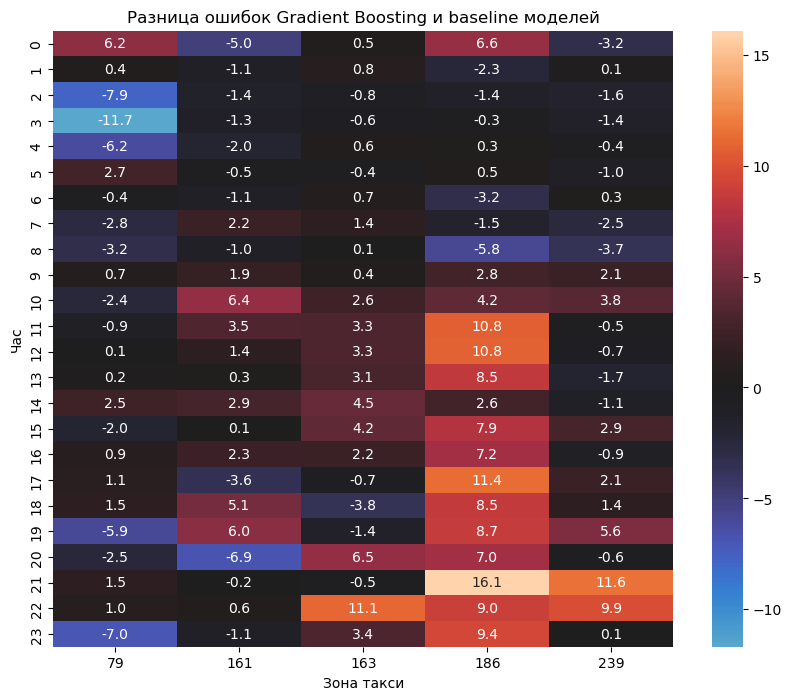

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

zone_hour_errors = (
    error_valid
    .groupby(["LocationID", "hour"])
    .agg(
        baseline_mae=("error_baseline", "mean"),
        gbr_mae=("error_gbr", "mean"),
        gain=("gain", "mean")
    )
    .reset_index()
)
pivot_gain = zone_hour_errors.pivot(index="hour",columns="LocationID",values="gain")

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_gain,center=0, annot=True, fmt=".1f")

plt.title("Разница ошибок Gradient Boosting и baseline моделей")
plt.ylabel("Час")
plt.xlabel("Зона такси")

plt.show()

Явно видно, что основное улучшение у boosting-модели произошло за счёт дневных и вечерних часов в зоне 186, тогда как в остальных зонах она в среднем показывает качество, близкое к baseline-модели. При этом в отдельных комбинациях зоны и часа наблюдаются резкие локальные различия в качестве моделей, например, около 0 и 23 часов в зоне 79, а также около 0 и 8 часов в зоне 186.

Посмотрим аналогичный хитмап для дня недели и часа и проанализируем его.

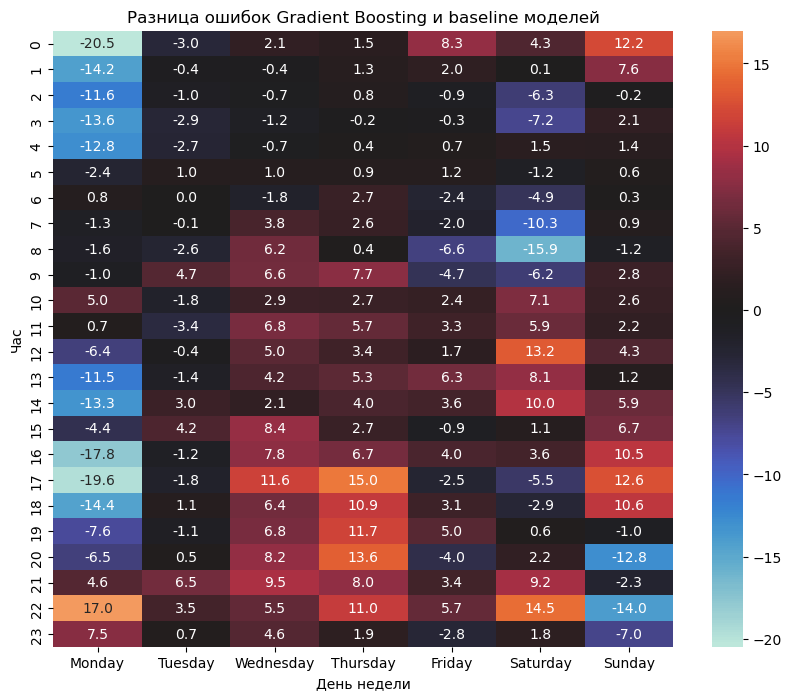

In [20]:
error_valid['weekday'] = error_valid['date'].dt.day_name()
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_hour_errors = (
    error_valid
    .groupby(["weekday", "hour"])
    .agg(
        baseline_mae=("error_baseline", "mean"),
        gbr_mae=("error_gbr", "mean"),
        gain=("gain", "mean")
    )
    .reset_index()
)
pivot_gain = day_hour_errors.pivot(index="hour",columns="weekday",values="gain")
pivot_gain = pivot_gain[weekday_order]

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_gain,center=0, annot=True, fmt=".1f")

plt.title("Разница ошибок Gradient Boosting и baseline моделей")
plt.ylabel("Час")
plt.xlabel("День недели")

plt.show()

Есть несколько зон хитмапа, в которых базовая модель предсказывает гораздо лучше gbr. Проблемные зоны: с 0 до 4 часов и с 12 до 20 часов понедельника; с 6 до 9 часов субботы; с 20 до 23 часов воскресенья. В остальные дни качества boosting иногда проседает относительно baseline, но не так критично. 
Напротив, есть и "хорошие" зоны: с 21 до 23 понедельника; примерно с 7 часов и до конца дня в среду и четверг; некоторые дневные и вечерние отрезки в субботу и воскресенье.

Недельный lag оказался сильным baseline, поэтому я переформулирую boosting как модель коррекции baseline, чтобы она училась не воспроизводить сезонность заново, а только предсказывать отклонение от неё. 

In [21]:
residual_train = y_train_1["pickups"]- y_train_pred_baseline
model_residual_gbr = GradientBoostingRegressor(random_state=42)

model_residual_gbr.fit(X_train_1,residual_train)
# Эта модель выдаёт не pickups, а прогноз поправки относительно baseline

residual_pred_train = model_residual_gbr.predict(X_train_1)
residual_pred_valid = model_residual_gbr.predict(X_valid_1)

# Превращаем в искомое предсказание модели
y_train_pred_residual_gbr = y_train_pred_baseline + residual_pred_train
y_valid_pred_residual_gbr = y_valid_pred_baseline + residual_pred_valid

mae_train_residual_gbr = mean_absolute_error(y_train_1["pickups"], y_train_pred_residual_gbr)
rmse_train_residual_gbr = np.sqrt(mean_squared_error(y_train_1["pickups"], y_train_pred_residual_gbr))

mae_valid_residual_gbr = mean_absolute_error(y_valid_1["pickups"], y_valid_pred_residual_gbr)
rmse_valid_residual_gbr = np.sqrt(mean_squared_error(y_valid_1["pickups"], y_valid_pred_residual_gbr))

print("MAE Residual GBR train:", mae_train_residual_gbr)
print("RMSE Residual GBR train:", rmse_train_residual_gbr)
print()
print("MAE Residual GBR validation:", mae_valid_residual_gbr)
print("RMSE Residual GBR validation:", rmse_valid_residual_gbr)

MAE Residual GBR train: 29.05809417796581
RMSE Residual GBR train: 47.667676778253934

MAE Residual GBR validation: 26.274453850449163
RMSE Residual GBR validation: 41.005911074123894


In [22]:
# Сравним ошибки всех 4 моделей

results = pd.DataFrame({
    "model": [
        "Baseline",
        "Linear Regression",
        "Gradient Boosting",
        "Residual Gradient Boosting"
    ],

    "train_mae": [
        mae_train_baseline,
        mae_train_1,
        mae_train_gbr,
        mae_train_residual_gbr
    ],

    "train_rmse": [
        rmse_train_baseline,
        rmse_train_1,
        rmse_train_gbr,
        rmse_train_residual_gbr
    ],

    "valid_mae": [
        mae_valid_baseline,
        mae_valid_1,
        mae_valid_gbr,
        mae_valid_residual_gbr
    ],

    "valid_rmse": [
        rmse_valid_baseline,
        rmse_valid_1,
        rmse_valid_gbr,
        rmse_valid_residual_gbr
    ]
})

results

,model,train_mae,train_rmse,valid_mae,valid_rmse
0,Baseline,34.047211,58.234397,27.769355,45.563774
1,Linear Regression,31.951011,52.838920,28.357227,44.489918
2,Gradient Boosting,29.070368,47.398224,26.498584,41.164810
3,Residual Gradient Boosting,29.058094,47.667677,26.274454,41.005911


Лучше всего себя показала последняя модель - Residual Gradient Boosting, хотя значения ошибок не сильно отличаются от предыдущей модели. Попробуем более тонко настроить её и посмотрим, как изменится качество.

### Функция ошибки
По умолчанию используется squared_error. Дополнительно рассмотрим absolute_error и Huber loss. Huber loss для небольших ошибок использует квадратичный штраф, а для больших — линейный, поэтому крупные ошибки и выбросы влияют на модель слабее, чем при squared_error.

In [23]:
losses = ["squared_error", "absolute_error", "huber"]

for loss in losses:
    model = GradientBoostingRegressor(loss=loss, random_state=42)
    model.fit(X_train_1, residual_train)

    residual_pred = model.predict(X_valid_1)
    y_pred = y_valid_pred_baseline + residual_pred

    mae = mean_absolute_error(y_valid_1["pickups"], y_pred)
    rmse = np.sqrt(mean_squared_error(y_valid_1["pickups"], y_pred))
    print(loss, mae, rmse)

squared_error 26.274453850449163 41.005911074123894
absolute_error 26.179602109450887 41.91954466782926
huber 26.096100766800554 41.2247570915343


MAE ближе всего к тому, что мы хотим минимизировать, поэтому остановлюсь на Huber loss. Значение средней абсолютной ошибки при этой функции потерь меньше всего и RMSE отличается несильно от минимального значения.

### Глубина
По умолчанию стоит max_depth=3, попробую увеличить глубину дерева. При этом буду контролировать ошибки на train и validation, ведь модель может переобучиться и надо вовремя остановиться.

In [24]:
depths = [3, 4, 5, 6, 7, 8, 9, 10, 12]

for depth in depths:
    model = GradientBoostingRegressor(loss="huber", max_depth=depth, random_state=42)
    model.fit(X_train_1, residual_train)

    residual_pred_valid = model.predict(X_valid_1)
    y_pred_valid = y_valid_pred_baseline + residual_pred_valid

    residual_pred_train = model.predict(X_train_1)
    y_pred_train = y_train_pred_baseline + residual_pred_train
    
    mae_train = mean_absolute_error(y_train_1["pickups"], y_pred_train)
    rmse_train = np.sqrt(mean_squared_error(y_train_1["pickups"], y_pred_train))
    
    mae_valid = mean_absolute_error(y_valid_1["pickups"], y_pred_valid)
    rmse_valid = np.sqrt(mean_squared_error(y_valid_1["pickups"], y_pred_valid))
    
    print(f'Глубина: {depth}')
    print(f'MAE train: {mae_train}, RMSE train: {rmse_train}')
    print(f'MAE valid: {mae_valid}, RMSE valid: {rmse_valid}')
    print()

Глубина: 3
MAE train: 28.690065534748957, RMSE train: 48.984938367744554
MAE valid: 26.096100766800554, RMSE valid: 41.2247570915343

Глубина: 4
MAE train: 27.37230437336433, RMSE train: 46.27290723180266
MAE valid: 25.45798175353655, RMSE valid: 40.106615604237696

Глубина: 5
MAE train: 25.888504327055212, RMSE train: 43.35488247990748
MAE valid: 24.844218888362903, RMSE valid: 39.15694070421758

Глубина: 6
MAE train: 24.37059824879822, RMSE train: 40.700108200080784
MAE valid: 24.400534982494747, RMSE valid: 38.65626827798767

Глубина: 7
MAE train: 22.591561911453134, RMSE train: 37.552121072157725
MAE valid: 23.89286412324873, RMSE valid: 38.11902759398102

Глубина: 8
MAE train: 21.055329169000547, RMSE train: 34.97790502195797
MAE valid: 23.882069332724452, RMSE valid: 38.17726179795276

Глубина: 9
MAE train: 19.47335859115588, RMSE train: 32.38950762019425
MAE valid: 23.838133462440492, RMSE valid: 38.0230990546213

Глубина: 10
MAE train: 17.34305393003455, RMSE train: 28.70380723

Заметно, что начиная с глубины 10 модель начала переобучаться, ошибка на трейне падает, но на валидации растёт, оставлю максимальную глубину, равную 9.

### Листья
По умолчанию min_samples_leaf=1, модель из-за этого может быть нестабильной. Попробуем увеличить значение и сделать правила менее локальными.

In [25]:
leafs = [1, 3, 5, 10, 15, 20]

for leaf in leafs:
    model = GradientBoostingRegressor(
        loss="huber", 
        max_depth=9, 
        min_samples_leaf=leaf, 
        random_state=42)
    model.fit(X_train_1, residual_train)

    residual_pred_valid = model.predict(X_valid_1)
    y_pred_valid = y_valid_pred_baseline + residual_pred_valid

    residual_pred_train = model.predict(X_train_1)
    y_pred_train = y_train_pred_baseline + residual_pred_train
    
    mae_train = mean_absolute_error(y_train_1["pickups"], y_pred_train)
    rmse_train = np.sqrt(mean_squared_error(y_train_1["pickups"], y_pred_train))
    
    mae_valid = mean_absolute_error(y_valid_1["pickups"], y_pred_valid)
    rmse_valid = np.sqrt(mean_squared_error(y_valid_1["pickups"], y_pred_valid))
    
    print(f'Минимальное количество объектов в листе: {leaf}')
    print(f'MAE train: {mae_train}, RMSE train: {rmse_train}')
    print(f'MAE valid: {mae_valid}, RMSE valid: {rmse_valid}')
    print()

Минимальное количество объектов в листе: 1
MAE train: 19.47335859115588, RMSE train: 32.38950762019425
MAE valid: 23.838133462440492, RMSE valid: 38.0230990546213

Минимальное количество объектов в листе: 3
MAE train: 19.802646151329544, RMSE train: 33.50719794764561
MAE valid: 23.811294143811487, RMSE valid: 38.0513063464496

Минимальное количество объектов в листе: 5
MAE train: 20.276878351120235, RMSE train: 34.58289457100163
MAE valid: 23.860276812543233, RMSE valid: 38.10966401036056

Минимальное количество объектов в листе: 10
MAE train: 21.28175143122378, RMSE train: 36.644390487324365
MAE valid: 23.63630857029834, RMSE valid: 37.84063513548966

Минимальное количество объектов в листе: 15
MAE train: 21.830063712891384, RMSE train: 37.595202945546575
MAE valid: 23.48218837335707, RMSE valid: 37.68091116790987

Минимальное количество объектов в листе: 20
MAE train: 22.59572161337787, RMSE train: 38.82120752684025
MAE valid: 23.80630453422562, RMSE valid: 38.17966311981625



При увеличении min_samples_leaf модель меньше опирается на локальные закономерности. При min_samples_leaf=15 validation MAE минимальна; при 20 ошибка снова начинает расти.

### Скорость обучения и количество деревьев
По умолчанию learning_rate=0.1, n_estimators=100. При уменьшении learning_rate каждое новое дерево аккуратнее корректирует текущий прогноз, при увеличении n_estimators увеличивается количество этих деревьев. Рассмотрим изменение этих показателей парами.

In [26]:
learning_rates = [0.1, 0.05, 0.01]
estimators = [100, 120, 150]

for rate in learning_rates:
    for estim in estimators:
        model = GradientBoostingRegressor(
            loss="huber", 
            max_depth=9,  
            min_samples_leaf=15,
            learning_rate=rate,
            n_estimators=estim,
            random_state=42)
        model.fit(X_train_1, residual_train)
    
        residual_pred_valid = model.predict(X_valid_1)
        y_pred_valid = y_valid_pred_baseline + residual_pred_valid
    
        residual_pred_train = model.predict(X_train_1)
        y_pred_train = y_train_pred_baseline + residual_pred_train
        
        mae_train = mean_absolute_error(y_train_1["pickups"], y_pred_train)
        rmse_train = np.sqrt(mean_squared_error(y_train_1["pickups"], y_pred_train))
        
        mae_valid = mean_absolute_error(y_valid_1["pickups"], y_pred_valid)
        rmse_valid = np.sqrt(mean_squared_error(y_valid_1["pickups"], y_pred_valid))
        
        print(f'Скорость: {rate}, деревья: {estim}')
        print(f'MAE train: {mae_train}, RMSE train: {rmse_train}')
        print(f'MAE valid: {mae_valid}, RMSE valid: {rmse_valid}')
        print()

Скорость: 0.1, деревья: 100
MAE train: 21.830063712891384, RMSE train: 37.595202945546575
MAE valid: 23.48218837335707, RMSE valid: 37.68091116790987

Скорость: 0.1, деревья: 120
MAE train: 21.327726474158087, RMSE train: 36.87149576204245
MAE valid: 23.365597469727433, RMSE valid: 37.57917934146064

Скорость: 0.1, деревья: 150
MAE train: 20.772345902685373, RMSE train: 36.09124989719449
MAE valid: 23.295951621046086, RMSE valid: 37.50745999288629

Скорость: 0.05, деревья: 100
MAE train: 23.558730556125955, RMSE train: 40.127135495891196
MAE valid: 23.95747839580875, RMSE valid: 38.24764684302245

Скорость: 0.05, деревья: 120
MAE train: 23.12292642820631, RMSE train: 39.469025838272465
MAE valid: 23.867518093793404, RMSE valid: 38.206971423489755

Скорость: 0.05, деревья: 150
MAE train: 22.616487479992767, RMSE train: 38.756616225698316
MAE valid: 23.75390478588572, RMSE valid: 38.12607298114228

Скорость: 0.01, деревья: 100
MAE train: 28.214866952342263, RMSE train: 47.98702079842956


При небольшом n_estimators уменьшение learning_rate приводит к росту ошибки, потому что каждое дерево вносит меньшую поправку и модель не успевает достаточно хорошо дообучиться. При увеличении n_estimators качество растёт и на train, и на validation. Попробую проверить другие комбинации и дойти до точки, где увеличение количества деревьев уже излишне.

In [27]:
learning_rates = [0.1, 0.05, 0.01]
estimators = [150, 200, 250, 300]

for rate in learning_rates:
    for estim in estimators:
        model = GradientBoostingRegressor(
            loss="huber", 
            max_depth=9,  
            min_samples_leaf=15,
            learning_rate=rate,
            n_estimators=estim,
            random_state=42)
        model.fit(X_train_1, residual_train)
    
        residual_pred_valid = model.predict(X_valid_1)
        y_pred_valid = y_valid_pred_baseline + residual_pred_valid
    
        residual_pred_train = model.predict(X_train_1)
        y_pred_train = y_train_pred_baseline + residual_pred_train
        
        mae_train = mean_absolute_error(y_train_1["pickups"], y_pred_train)
        rmse_train = np.sqrt(mean_squared_error(y_train_1["pickups"], y_pred_train))
        
        mae_valid = mean_absolute_error(y_valid_1["pickups"], y_pred_valid)
        rmse_valid = np.sqrt(mean_squared_error(y_valid_1["pickups"], y_pred_valid))
        
        print(f'Скорость: {rate}, деревья: {estim}')
        print(f'MAE train: {mae_train}, RMSE train: {rmse_train}')
        print(f'MAE valid: {mae_valid}, RMSE valid: {rmse_valid}')
        print()

Скорость: 0.1, деревья: 150
MAE train: 20.772345902685373, RMSE train: 36.09124989719449
MAE valid: 23.295951621046086, RMSE valid: 37.50745999288629

Скорость: 0.1, деревья: 200
MAE train: 20.07231554388944, RMSE train: 35.092347148173246
MAE valid: 23.257371407402236, RMSE valid: 37.462709279369946

Скорость: 0.1, деревья: 250
MAE train: 19.6207734488967, RMSE train: 34.45436902560087
MAE valid: 23.25552114028369, RMSE valid: 37.490736731297545

Скорость: 0.1, деревья: 300
MAE train: 19.123008178067263, RMSE train: 33.715677083054835
MAE valid: 23.315852022399227, RMSE valid: 37.56854911237398

Скорость: 0.05, деревья: 150
MAE train: 22.616487479992767, RMSE train: 38.756616225698316
MAE valid: 23.75390478588572, RMSE valid: 38.12607298114228

Скорость: 0.05, деревья: 200
MAE train: 21.920695182649993, RMSE train: 37.703715123107706
MAE valid: 23.609028001479366, RMSE valid: 37.9799846656446

Скорость: 0.05, деревья: 250
MAE train: 21.405757563473728, RMSE train: 36.94344613128851
MA

Комбинация (0.1, 200) дала наиболее разумный компромисс между качеством и сложностью модели, хотя минимальная MAE получена при другом числе деревьев. При n_estimators=250 на валидации MAE понизилась лишь на тысячную долю и RMSE выросла, ошибки на трейне сильно упали. То есть это сигнал о том, что разумнее оставить 200 деревьев.

На этом закончу настройку параметров модели и закреплю её финальную версию.

In [28]:
model_final_gbr = GradientBoostingRegressor(
    loss="huber", 
    max_depth=9,  
    min_samples_leaf=15,
    learning_rate=0.1,
    n_estimators=200,
    random_state=42)
model_final_gbr.fit(X_train_1, residual_train)

residual_pred_valid = model_final_gbr.predict(X_valid_1)
y_pred_valid = y_valid_pred_baseline + residual_pred_valid

residual_pred_train = model_final_gbr.predict(X_train_1)
y_pred_train = y_train_pred_baseline + residual_pred_train

mae_train_final_gbr = mean_absolute_error(y_train_1["pickups"], y_pred_train)
rmse_train_final_gbr = np.sqrt(mean_squared_error(y_train_1["pickups"], y_pred_train))

mae_valid_final_gbr = mean_absolute_error(y_valid_1["pickups"], y_pred_valid)
rmse_valid_final_gbr = np.sqrt(mean_squared_error(y_valid_1["pickups"], y_pred_valid))

new_row = pd.DataFrame([{
    'model': 'Final Residual GBR',
    'train_mae': mae_train_final_gbr,
    'train_rmse': rmse_train_final_gbr,
    'valid_mae': mae_valid_final_gbr,
    'valid_rmse': rmse_valid_final_gbr
}])

results = pd.concat([results, new_row], ignore_index=True)
results

,model,train_mae,train_rmse,valid_mae,valid_rmse
0,Baseline,34.047211,58.234397,27.769355,45.563774
1,Linear Regression,31.951011,52.838920,28.357227,44.489918
2,Gradient Boosting,29.070368,47.398224,26.498584,41.164810
3,Residual Gradient Boosting,29.058094,47.667677,26.274454,41.005911
4,Final Residual GBR,20.072316,35.092347,23.257371,37.462709


## ЧАСТЬ 4: Модель с данными о концертах
Мы определили финальный вид модели, теперь обучим её на тех же данных, но добавим в них признак event_day, то есть информацию о концерте в этом районе. Изучим, как влияет этот признак на качество модели.

In [29]:
X_train_2 = X_train_1.copy()
X_valid_2 = X_valid_1.copy()
X_test_2 = X_test_1.copy()

X_train_2["event_day"] = taxi.loc[X_train_2.index, "event_day"]
X_valid_2["event_day"] = taxi.loc[X_valid_2.index, "event_day"]
X_test_2["event_day"] = taxi.loc[X_test_2.index, "event_day"]

In [30]:
model_event = GradientBoostingRegressor(
    loss="huber", 
    max_depth=9,  
    min_samples_leaf=15,
    learning_rate=0.1,
    n_estimators=200,
    random_state=42)
model_event.fit(X_train_2, residual_train)

pred_valid = model_event.predict(X_valid_2)
y_pred_valid = y_valid_pred_baseline + pred_valid

pred_train = model_event.predict(X_train_2)
y_pred_train = y_train_pred_baseline + pred_train

mae_train_event = mean_absolute_error(y_train_1["pickups"], y_pred_train)
rmse_train_event = np.sqrt(mean_squared_error(y_train_1["pickups"], y_pred_train))

mae_valid_event = mean_absolute_error(y_valid_1["pickups"], y_pred_valid)
rmse_valid_event = np.sqrt(mean_squared_error(y_valid_1["pickups"], y_pred_valid))

print("MAE train_event:", mae_train_event)
print("RMSE train_event:", rmse_train_event)
print()
print("MAE valid_event:", mae_valid_event)
print("RMSE valid_event:", rmse_valid_event)
print()
print()
print("MAE train_no_event:", mae_train_final_gbr)
print("RMSE train_no_event:", rmse_train_final_gbr)
print()
print("MAE valid_no_event:", mae_valid_final_gbr)
print("RMSE valid_no_event:", rmse_valid_final_gbr)

MAE train_event: 19.914093532216757
RMSE train_event: 34.75631248405478

MAE valid_event: 23.543569152649184
RMSE valid_event: 37.77234493885427


MAE train_no_event: 20.07231554388944
RMSE train_no_event: 35.092347148173246

MAE valid_no_event: 23.257371407402236
RMSE valid_no_event: 37.462709279369946


Ошибка новой модели на трейне меньше, но немного увеличилась ошибка на валидации.
Изменения относительно значений ошибок no_event модели:
- MAE на трейне -0.8%
- RMSE на трейне -1%
- MAE на валидации +1.2%
- RMSE на валидации +0.8%

В целом добавление event_day не улучшило validation-качество. Поскольку влияние концертного признака логично ожидать прежде всего в концертные дни, дополнительно проверим качество именно на этой подвыборке.

In [31]:
# Фиксируем предсказания моделей, которые сравниваем

residual_pred_valid_no_event = model_final_gbr.predict(X_valid_1)
y_pred_valid_no_event = y_valid_pred_baseline + residual_pred_valid_no_event

residual_pred_valid_event = model_event.predict(X_valid_2)
y_pred_valid_event = y_valid_pred_baseline + residual_pred_valid_event

comparison_valid = taxi.loc[y_valid_1.index,["date", "hour", "LocationID", "event_day"]].copy()
comparison_valid["y_true"] = y_valid_1["pickups"].to_numpy()

comparison_valid["pred_no_event"] = y_pred_valid_no_event
comparison_valid["pred_event"] = y_pred_valid_event

comparison_valid["error_no_event"] = abs(comparison_valid["y_true"] - comparison_valid["pred_no_event"])
comparison_valid["error_event"] = abs(comparison_valid["y_true"] - comparison_valid["pred_event"])

comparison_valid["sq_error_no_event"] = (
    comparison_valid["y_true"]
    - comparison_valid["pred_no_event"]
) ** 2

comparison_valid["sq_error_event"] = (
    comparison_valid["y_true"]
    - comparison_valid["pred_event"]
) ** 2

In [32]:
event_comparison = (
    comparison_valid
    .groupby("event_day")
    .agg(
        mae_no_event=("error_no_event", "mean"),
        mae_event=("error_event", "mean"),
        mse_no_event=("sq_error_no_event", "mean"),
        mse_event=("sq_error_event", "mean")
    )
    .reset_index()
)

event_comparison["rmse_no_event"] = np.sqrt(event_comparison["mse_no_event"])
event_comparison["rmse_event"] = np.sqrt(event_comparison["mse_event"])

event_comparison["mae_gain"] = event_comparison["mae_no_event"] - event_comparison["mae_event"]
event_comparison["rmse_gain"] = event_comparison["rmse_no_event"]- event_comparison["rmse_event"]

event_comparison[[
    "event_day",
    "mae_no_event",
    "mae_event",
    "mae_gain",
    "rmse_no_event",
    "rmse_event",
    "rmse_gain"
]]

,event_day,mae_no_event,mae_event,mae_gain,rmse_no_event,rmse_event,rmse_gain
0,0,22.991801,23.325285,-0.333484,37.414122,37.891150,-0.477028
1,1,23.849371,24.030160,-0.180789,37.570792,37.506154,0.064638


Добавление бинарного event_day не дало заметного улучшения качества на validation и даже немного его ухудшило; различия между моделями малы.

In [33]:
event_evening = comparison_valid[
    (comparison_valid["event_day"] == 1)
    & (comparison_valid["hour"] >= 18)
]

event_evening[[
    "error_no_event",
    "error_event"
]].mean()

mae_no_event_evening = (
    event_evening["error_no_event"].mean()
)

mae_event_evening = (
    event_evening["error_event"].mean()
)

print("MAE без event_day:", mae_no_event_evening)
print("MAE с event_day:", mae_event_evening)
print(
    "gain:",
    mae_no_event_evening - mae_event_evening
)

MAE без event_day: 34.50508951754719
MAE с event_day: 34.70000298041599
gain: -0.19491346286879718


На концертных вечерних часах добавление event_day также не дало улучшения MAE; качество двух моделей практически одинаково.

In [34]:
event_evening_zone = (
    comparison_valid[
        (comparison_valid["event_day"] == 1)
        & (comparison_valid["hour"] >= 18)
    ]
    .groupby("LocationID")
    .agg(
        event_dates=("date", "nunique"),
        mae_no_event=("error_no_event", "mean"),
        mae_event=("error_event", "mean")
    )
    .reset_index()
)

event_evening_zone["gain"] = event_evening_zone["mae_no_event"] - event_evening_zone["mae_event"]
event_evening_zone

,LocationID,event_dates,mae_no_event,mae_event,gain
0,79,19,26.541881,29.045869,-2.503988
1,161,7,43.778111,44.918679,-1.140568
2,163,4,47.927134,48.859826,-0.932692
3,186,11,42.264035,38.037828,4.226206
4,239,7,26.984124,26.491780,0.492344


In [35]:
event_late_evening = comparison_valid[
    (comparison_valid["event_day"] == 1)
    & (comparison_valid["hour"] >= 21)
]

late_evening_zone = (
    event_late_evening
    .groupby("LocationID")
    .agg(
        event_dates=("date", "nunique"),
        mae_no_event=("error_no_event", "mean"),
        mae_event=("error_event", "mean")
    )
    .reset_index()
)

late_evening_zone["gain"] = late_evening_zone["mae_no_event"] - late_evening_zone["mae_event"]
late_evening_zone

,LocationID,event_dates,mae_no_event,mae_event,gain
0,79,19,29.689136,33.553610,-3.864474
1,161,7,41.179873,41.535207,-0.355334
2,163,4,62.317328,60.610946,1.706383
3,186,11,44.185541,39.395393,4.790148
4,239,7,34.789599,34.300613,0.488986


Первая таблица показывает изменение точности предсказаний по площадкам в вечернее время. Вторая таблица показывает то же самое, но с 21 до 23 часов. Положительный gain - концертная модель лучше предсказывает, отрицательный - хуже.

Эффект event_day явно неоднороден по площадкам. Изменения MAE на валидации относительно no_event модели с 21 до 23 часов, где положительный процент означает прирост МАЕ, то есть ухудшение модели с данными о концертах:
- 79 зона: +13%
- 161 зона: +0.9%
- 163 зона: -2.7%
- 186 зона: -11%
- 239 зона: -1.4%


В концертные дни в зоне Madison Square Garden информация о наличии концерта улучшает прогноз примерно на 4 поездки в вечерние часы, причём эффект сохраняется и усиливается в окне 21–23. Это не случайно выбранное окно: поздний вечер у MSG выделялся ещё на EDA. Единственный бинарный event_day не улучшает общий прогноз по пяти площадкам, например MAE зоны 79 ухудшился в поздние часы на 13%, это заметная деградация прогнозов модели.

### Другая версия модели с данными о концертах

Как я заметила выше, на разные зоны концертная информация влияет очень по-разному. Попробую вместо одного бинарного признака добавить 5 бинарных признаков. Конечно, эта информация уже зашита в LocationID x event_day и дерево могло обнаружить эти закономерности. Возможно, подача данных напрямую может улучшить качество предсказаний модели.

In [36]:
X_train_3 = X_train_1.copy()
X_valid_3 = X_valid_1.copy()
X_test_3 = X_test_1.copy()

taxi["event_Madison"] = ((taxi["event_day"] == 1) & (taxi["LocationID"] == 186)).astype(int)
taxi["event_RadioCity"] = ((taxi["event_day"] == 1) & (taxi["LocationID"] == 161)).astype(int)
taxi["event_IsaacStern"] = ((taxi["event_day"] == 1) & (taxi["LocationID"] == 163)).astype(int)
taxi["event_WebsterHall"] = ((taxi["event_day"] == 1) & (taxi["LocationID"] == 79)).astype(int)
taxi["event_Beacon"] = ( (taxi["event_day"] == 1) & (taxi["LocationID"] == 239)).astype(int)

event_features = [
    "event_Madison",
    "event_RadioCity",
    "event_IsaacStern",
    "event_WebsterHall",
    "event_Beacon"
]

for feature in event_features:
    X_train_3[feature] = taxi.loc[X_train_3.index, feature]
    X_valid_3[feature] = taxi.loc[X_valid_3.index, feature]
    X_test_3[feature] = taxi.loc[X_test_3.index, feature]

In [37]:
model_event_5 = GradientBoostingRegressor(
    loss="huber", 
    max_depth=9,  
    min_samples_leaf=15,
    learning_rate=0.1,
    n_estimators=200,
    random_state=42)
model_event_5.fit(X_train_3, residual_train)

pred_valid_event_5 = model_event_5.predict(X_valid_3)
y_pred_valid_event_5 = y_valid_pred_baseline + pred_valid_event_5

pred_train_event_5 = model_event_5.predict(X_train_3)
y_pred_train_event_5 = y_train_pred_baseline + pred_train_event_5

mae_train_event_5 = mean_absolute_error(y_train_1["pickups"], y_pred_train_event_5)
rmse_train_event_5 = np.sqrt(mean_squared_error(y_train_1["pickups"], y_pred_train_event_5))

mae_valid_event_5 = mean_absolute_error(y_valid_1["pickups"], y_pred_valid_event_5)
rmse_valid_event_5 = np.sqrt(mean_squared_error(y_valid_1["pickups"], y_pred_valid_event_5))

In [38]:
new_row_1 = pd.DataFrame([{
    'model': 'Event model',
    'train_mae': mae_train_event,
    'train_rmse': rmse_train_event,
    'valid_mae': mae_valid_event,
    'valid_rmse': rmse_valid_event
}])
new_row_2 = pd.DataFrame([{
    'model': 'Event model 5',
    'train_mae': mae_train_event_5,
    'train_rmse': rmse_train_event_5,
    'valid_mae': mae_valid_event_5,
    'valid_rmse': rmse_valid_event_5
}])

results = pd.concat([results, new_row_1, new_row_2], ignore_index=True)
results

,model,train_mae,train_rmse,valid_mae,valid_rmse
0,Baseline,34.047211,58.234397,27.769355,45.563774
1,Linear Regression,31.951011,52.838920,28.357227,44.489918
2,Gradient Boosting,29.070368,47.398224,26.498584,41.164810
3,Residual Gradient Boosting,29.058094,47.667677,26.274454,41.005911
4,Final Residual GBR,20.072316,35.092347,23.257371,37.462709
5,Event model,19.914094,34.756312,23.543569,37.772345
6,Event model 5,20.050783,34.883865,23.551111,37.828804


Пять отдельных признаков не помогли и даже получились чуть хуже одного event_day.

## ЧАСТЬ 5: Сравнение моделей на тесте и вывод

Пока что мы работали только с трейном для обучения моделей и с валидацией для подбора гиперпараметров, отложенный тест не был использован ни разу. Проверим предсказания моделей на тесте.

In [39]:
y_test_pred_baseline = (
    taxi.loc[y_test_1.index, "lag_168"]
    + taxi.loc[y_test_1.index, "lag_168_missing"] * mean_train_pickups
)

# Модель без концертов
residual_pred_test_no_event = model_final_gbr.predict(X_test_1)
y_pred_test_no_event = y_test_pred_baseline + residual_pred_test_no_event

mae_test_no_event = mean_absolute_error(y_test_1["pickups"], y_pred_test_no_event)
rmse_test_no_event = np.sqrt(mean_squared_error(y_test_1["pickups"], y_pred_test_no_event))

# Модель с концертами
residual_pred_test_event = model_event.predict(X_test_2)
y_pred_test_event = (y_test_pred_baseline + residual_pred_test_event)

mae_test_event = mean_absolute_error(y_test_1["pickups"], y_pred_test_event)
rmse_test_event = np.sqrt(mean_squared_error(y_test_1["pickups"], y_pred_test_event))


print("MAE test_no_event:", mae_test_no_event)
print("RMSE test_no_event:", rmse_test_no_event)
print()
print()
print("MAE test_event:", mae_test_event)
print("RMSE test_event:", rmse_test_event)

MAE test_no_event: 32.246705004134625
RMSE test_no_event: 54.71416023210444


MAE test_event: 32.154534732494255
RMSE test_event: 54.43204068661446


На тесте заметные малые уменьшения ошибки для модели с концертами относительно модели без концертов. Рассмотрим ошибки для концертных дней в вечернее время. Как и ранее, сгруппируем их по зонам.

In [40]:
comparison_test = taxi.loc[
    y_test_1.index,
    ["date", "hour", "LocationID", "event_day"]
].copy()

comparison_test["y_true"] = y_test_1["pickups"].to_numpy()

comparison_test["pred_no_event"] = y_pred_test_no_event
comparison_test["pred_event"] = y_pred_test_event

comparison_test["error_no_event"] = abs(comparison_test["y_true"] - comparison_test["pred_no_event"])
comparison_test["error_event"] = abs(comparison_test["y_true"] - comparison_test["pred_event"])

event_evening_test = comparison_test[
    (comparison_test["event_day"] == 1)
    & (comparison_test["hour"] >= 18)
]

mae_no_event_evening_test = event_evening_test["error_no_event"].mean()
mae_event_evening_test = event_evening_test["error_event"].mean()

rmse_no_event_evening_test = np.sqrt(
    mean_squared_error(
        event_evening_test["y_true"],
        event_evening_test["pred_no_event"]
    )
)
rmse_event_evening_test = np.sqrt(
    mean_squared_error(
        event_evening_test["y_true"],
        event_evening_test["pred_event"]
    )
)

print('Ошибки для концертных дней в вечернее время')
print("MAE no_event:", mae_no_event_evening_test)
print("MAE event:", mae_event_evening_test)
print("MAE gain:", mae_no_event_evening_test - mae_event_evening_test)
print()
print("RMSE no_event:", rmse_no_event_evening_test)
print("RMSE event:", rmse_event_evening_test)
print("RMSE gain:",rmse_no_event_evening_test - rmse_event_evening_test)

Ошибки для концертных дней в вечернее время
MAE no_event: 47.75030647082952
MAE event: 47.5180839960107
MAE gain: 0.23222247481881908

RMSE no_event: 69.63388560100091
RMSE event: 69.64456593270786
RMSE gain: -0.010680331706950597


Заметных различий не наблюдаю.

In [41]:
event_evening_zone = (
    comparison_test[
        (comparison_test["event_day"] == 1)
        & (comparison_test["hour"] >= 18)
    ]
    .groupby("LocationID")
    .agg(
        event_dates=("date", "nunique"),
        mae_no_event=("error_no_event", "mean"),
        mae_event=("error_event", "mean")
    )
    .reset_index()
)

event_evening_zone["gain"] = event_evening_zone["mae_no_event"] - event_evening_zone["mae_event"]
event_evening_zone

,LocationID,event_dates,mae_no_event,mae_event,gain
0,79,26,57.170418,56.247181,0.923236
1,161,2,56.997596,59.568427,-2.570831
2,163,8,36.731823,35.401545,1.330278
3,186,12,43.030223,42.895752,0.134471
4,239,23,42.592541,43.228653,-0.636111


In [42]:
event_late_evening = comparison_test[
    (comparison_test["event_day"] == 1)
    & (comparison_test["hour"] >= 21)
]

late_evening_zone = (
    event_late_evening
    .groupby("LocationID")
    .agg(
        event_dates=("date", "nunique"),
        mae_no_event=("error_no_event", "mean"),
        mae_event=("error_event", "mean")
    )
    .reset_index()
)

late_evening_zone["gain"] = late_evening_zone["mae_no_event"] - late_evening_zone["mae_event"]
late_evening_zone

,LocationID,event_dates,mae_no_event,mae_event,gain
0,79,26,68.887319,69.544244,-0.656926
1,161,2,37.511315,33.799775,3.711540
2,163,8,39.784277,37.540913,2.243364
3,186,12,53.204308,54.146993,-0.942686
4,239,23,42.937991,42.360970,0.577021


- В зоне 79 при сужении временного окна до 21–23 часов модель с концертными данными показала результат хуже, хотя в окне 18–23 часов давала небольшой прирост качества.
- Вероятно, из-за малого количества концертных дней в зоне 161 произошёл резкий скачок качества, поэтому полностью доверять полученным результатам по этой зоне нельзя.
- В зонах 163 и 239 при сужении временного окна качество модели с концертными данными улучшилось.
- В отличие от валидации, в зоне 186 концертная модель с 21 до 23 часов ухудшила качество.

### Вывод
Признак event_day = «был ли в этот день концерт в этой зоне» не дал заметных улучшений качества модели, а в некоторых случаях даже ухудшил его. Возможно, это произошло из-за ограниченности данных, а также из-за того, что сам признак сконструирован слишком просто.

Однако при поиске информации о концертах я не смогла найти источник, который предоставлял бы достоверную информацию в достаточном количестве и при этом содержал время проведения концерта и количество проданных билетов. Такая информация была бы очень полезна для моего исследования и могла бы изменить результаты исследовательского проекта.

Кроме добавления более подробной информации о концертах, перспективой развития проекта является расширение данных на другие виды такси. В проекте я использовала Parquet-файлы только для жёлтых такси, однако сейчас люди часто вызывают такси с помощью приложений, поэтому в дальнейшем можно добавить данные о таких поездках.

Также можно расширить период наблюдений и количество концертных площадок, чтобы увеличить объём данных и проверить, сохраняются ли полученные результаты на более крупной выборке.